# Probability Distributions for Business Stats
**CTP Data Science — Week 05: Stats and Business Analytics**

This notebook is split into three levels. Go as far as you can:

| Level | What you'll learn |
|---|---|
| 🟢 **Beginner** | What a distribution is, the 8 you'll see most in business, and what each looks like |
| 🟡 **Intermediate** | Using distributions to answer real business questions (probabilities, percentiles, staffing, SLAs, confidence intervals) |
| 🔴 **Advanced** | Fitting distributions to data, A/B testing (frequentist + Bayesian), bootstrapping, and Monte Carlo simulation |

Each level ends with exercises.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

rng = np.random.default_rng(42)   # fixed seed so everyone gets the same numbers
plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

---
# 🟢 Beginner: Meet the Distributions

A **probability distribution** describes how likely each possible outcome is.
If you recorded 10,000 customers' order values and made a histogram, the *shape* of that histogram is the distribution.

Two big families:
- **Discrete**: outcomes you can count (0, 1, 2, … purchases). Described by a **PMF** (probability mass function).
- **Continuous**: outcomes you measure (3.72 minutes, $48.10). Described by a **PDF** (probability density function).

We'll use a small helper to simulate each distribution and plot it with its mean and median.

In [2]:
def show(samples, title, discrete=False, bins=40):
    fig, ax = plt.subplots()
    if discrete:
        vals, counts = np.unique(samples, return_counts=True)
        ax.bar(vals, counts / len(samples), color="steelblue", alpha=0.8)
        ax.set_ylabel("probability")
    else:
        ax.hist(samples, bins=bins, density=True, color="steelblue", alpha=0.8)
        ax.set_ylabel("density")
    mean, median = np.mean(samples), np.median(samples)
    ax.axvline(mean, color="crimson", lw=2, label=f"mean = {mean:,.2f}")
    ax.axvline(median, color="orange", lw=2, ls="--", label=f"median = {median:,.2f}")
    ax.set_title(title)
    ax.legend()
    plt.show()

## 1. Bernoulli: one yes/no trial
**Business story:** A single visitor lands on your site. Do they buy (1) or not (0)? Conversion rate `p = 0.08`.

In [3]:
visitor_bought = rng.binomial(n=1, p=0.08, size=10_000)
print("First 20 visitors:", visitor_bought[:20])
print("Observed conversion rate:", visitor_bought.mean())

First 20 visitors: [0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0]
Observed conversion rate: 0.0785


## 2. Binomial: number of successes in n trials
**Business story:** 500 visitors per day, each converts with `p = 0.08`. How many sales per day?
The binomial is just the sum of many Bernoullis. **This is the distribution behind A/B testing.**

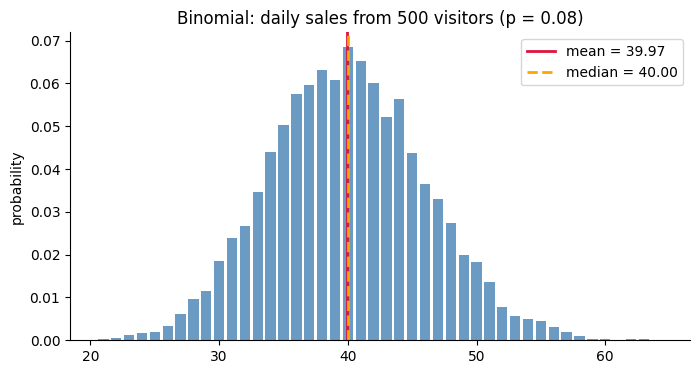

In [4]:
daily_sales = rng.binomial(n=500, p=0.08, size=10_000)
show(daily_sales, "Binomial: daily sales from 500 visitors (p = 0.08)", discrete=True)

## 3. Normal: the bell curve
**Business story:** Delivery times average 3 days with a standard deviation of 0.5 days.
Symmetric, and the mean and median are the same. Shows up whenever lots of small, independent effects add together.

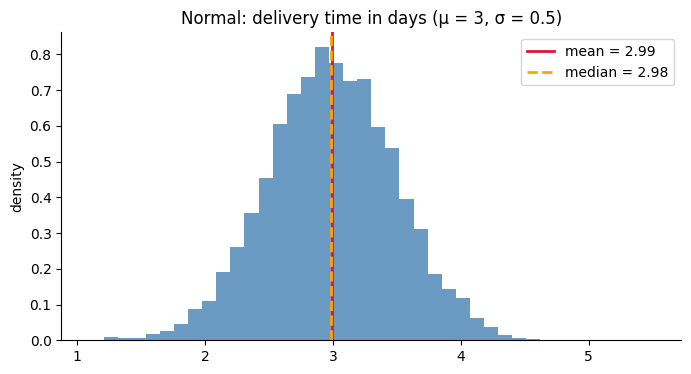

In [5]:
delivery_days = rng.normal(loc=3, scale=0.5, size=10_000)
show(delivery_days, "Normal: delivery time in days (μ = 3, σ = 0.5)")

## 4. Poisson: counts of events in a time window
**Business story:** A support desk receives on average 12 tickets per hour. How many arrive in a given hour?
Use Poisson when events happen independently at a steady average rate `λ` (lambda).

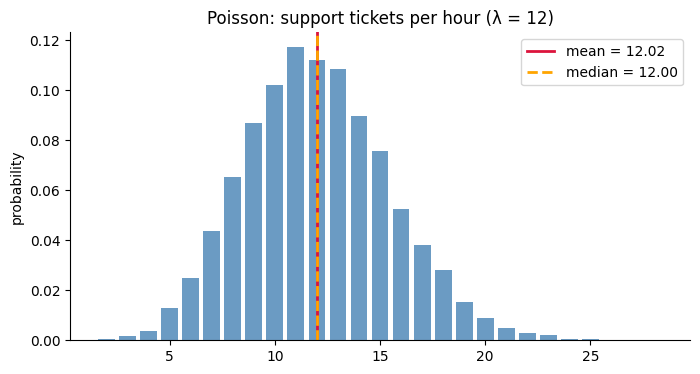

In [6]:
tickets_per_hour = rng.poisson(lam=12, size=10_000)
show(tickets_per_hour, "Poisson: support tickets per hour (λ = 12)", discrete=True)

## 5. Exponential: time *between* events
**Business story:** If tickets arrive at 12/hour, the average gap between tickets is 60/12 = 5 minutes.
Poisson counts events; exponential measures the waiting time between them. They're two views of the same process.

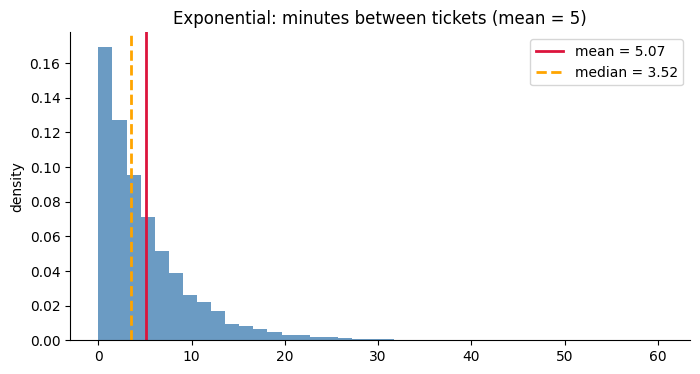

In [7]:
minutes_between = rng.exponential(scale=5, size=10_000)
show(minutes_between, "Exponential: minutes between tickets (mean = 5)")

## 6. Uniform: every value equally likely
**Business story:** A promo gives a random discount between 5% and 25%. Mostly used as a baseline or for simulation.

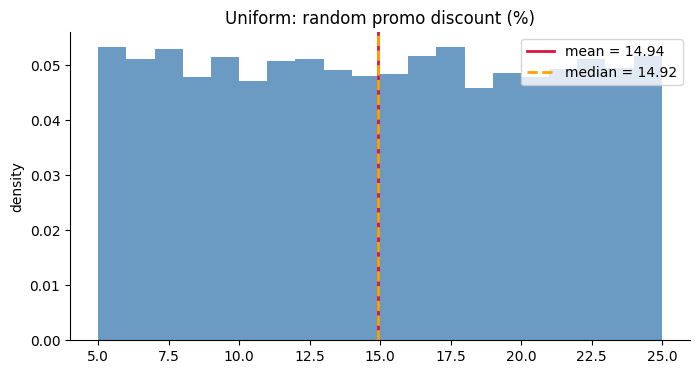

In [8]:
discount = rng.uniform(low=5, high=25, size=10_000)
show(discount, "Uniform: random promo discount (%)", bins=20)

## 7. Log-normal: skewed, long right tail
**Business story:** Revenue per customer. Most people spend a little, a few spend a LOT.
Notice how the **mean gets dragged above the median**. This is why "average revenue per customer" can be misleading.

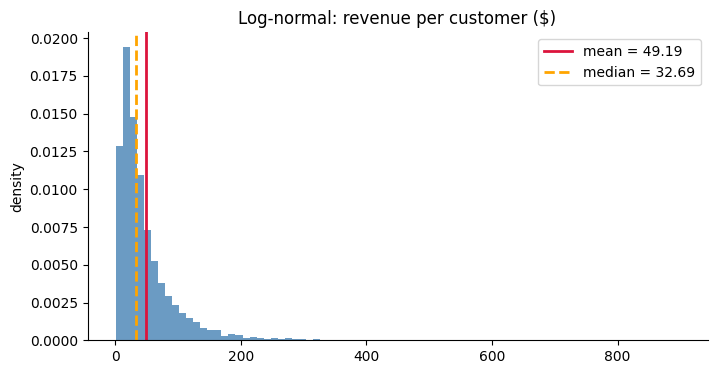

In [9]:
revenue_per_customer = rng.lognormal(mean=3.5, sigma=0.9, size=10_000)
show(revenue_per_customer, "Log-normal: revenue per customer ($)", bins=80)

## 8. Pareto: the 80/20 rule
**Business story:** A handful of products (or customers, or salespeople) generate most of the revenue.
Even more extreme tail than log-normal.

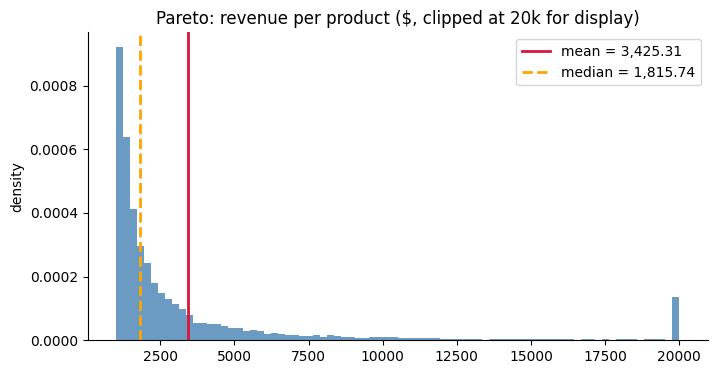

In [10]:
product_revenue = (rng.pareto(a=1.16, size=10_000) + 1) * 1_000
show(np.clip(product_revenue, None, 20_000), "Pareto: revenue per product ($, clipped at 20k for display)", bins=80)

## Cheat sheet

| Distribution | Type | Use it when… | Business example |
|---|---|---|---|
| Bernoulli | discrete | one yes/no outcome | did this user convert? |
| Binomial | discrete | # of yeses out of n tries | conversions out of 500 visitors |
| Poisson | discrete | # of events per time window | tickets per hour, orders per day |
| Normal | continuous | symmetric, clusters around average | delivery time, measurement error |
| Exponential | continuous | time between random events | minutes until next customer |
| Uniform | continuous | all values equally likely | random discount, simulation seed |
| Log-normal | continuous | positive, right-skewed | revenue per customer, salaries |
| Pareto | continuous | extreme "winner-take-most" | revenue per product, 80/20 |

(The **t-distribution** also matters a lot, but it's used for *inference*, so we'll meet it in the Intermediate section.)

## 🟢 Beginner Exercises
1. A cafe gets on average 30 customers per hour. Which distribution models customers per hour? Simulate 10,000 hours and plot it with `show()`.
2. Simulate 10,000 salaries with `rng.lognormal(mean=11, sigma=0.5, size=10_000)`. What's the mean? The median? Which would you report in a job posting, and why?
3. In your own words: why are the mean and median equal for the normal distribution but not for the log-normal?

In [11]:
# Your code here

---
# 🟡 Intermediate: Answering Business Questions

Simulation is great for intuition, but `scipy.stats` gives exact answers. Every distribution object has the same methods:

| Method | Question it answers | Example |
|---|---|---|
| `.pmf(k)` / `.pdf(x)` | How likely is exactly this value? | P(exactly 40 sales) |
| `.cdf(x)` | P(value ≤ x)? | P(12 or fewer tickets) |
| `.sf(x)` | P(value > x)? (= 1 − cdf) | P(more than 20 tickets) |
| `.ppf(q)` | What value is at the q-th percentile? | 95th-percentile delivery time |
| `.rvs(size)` | Give me random samples | simulation |

## Q1 (Binomial): Is today's conversion number suspicious?
500 visitors, normal conversion rate 8% (expected 40 sales). Today we got **only 28 sales**. How unusual is 28 or fewer if nothing actually changed?

In [12]:
sales = stats.binom(n=500, p=0.08)
p_28_or_less = sales.cdf(28)
print(f"Expected sales: {sales.mean():.0f}")
print(f"P(28 or fewer sales | nothing changed) = {p_28_or_less:.4f}")

Expected sales: 40
P(28 or fewer sales | nothing changed) = 0.0246


About 2.5%. That's unusual enough that it's worth checking whether something broke (checkout bug, ad campaign ended), though not impossible by chance alone.
**This is exactly the logic behind a p-value.**

## Q2 (Poisson): How many support agents do we need?
Tickets arrive at λ = 12/hour. Each agent can handle 4 tickets/hour. We want to be overwhelmed **less than 5% of the time**.

In [13]:
tickets = stats.poisson(mu=12)
capacity_per_agent = 4

for agents in range(2, 8):
    capacity = agents * capacity_per_agent
    p_overwhelmed = tickets.sf(capacity)   # P(tickets > capacity)
    flag = "✅" if p_overwhelmed < 0.05 else ""
    print(f"{agents} agents (capacity {capacity:>2}): P(overwhelmed) = {p_overwhelmed:.3f} {flag}")

2 agents (capacity  8): P(overwhelmed) = 0.845 
3 agents (capacity 12): P(overwhelmed) = 0.424 
4 agents (capacity 16): P(overwhelmed) = 0.101 
5 agents (capacity 20): P(overwhelmed) = 0.012 ✅
6 agents (capacity 24): P(overwhelmed) = 0.001 ✅
7 agents (capacity 28): P(overwhelmed) = 0.000 ✅


Three agents cover the *average* (12 tickets), but they'd be overwhelmed ~42% of hours. You need **5 agents** to get below 5%.
Lesson: **planning for the average means failing almost half the time.**

## Q3 (Exponential): How often does a customer wait too long?
Customers arrive every 5 minutes on average. What fraction of gaps are shorter than 1 minute (two customers nearly back-to-back)?

In [14]:
gap = stats.expon(scale=5)
print(f"P(next customer within 1 min)  = {gap.cdf(1):.3f}")
print(f"P(gap longer than 15 min)       = {gap.sf(15):.3f}")
print(f"Median gap                      = {gap.median():.2f} min  (vs mean 5)")

P(next customer within 1 min)  = 0.181
P(gap longer than 15 min)       = 0.050
Median gap                      = 3.47 min  (vs mean 5)


## Q4 (Normal): Setting a delivery promise (SLA)
Delivery takes μ = 3 days, σ = 0.5. What should we promise so that **95% of orders arrive on time**?

In [15]:
delivery = stats.norm(loc=3, scale=0.5)
promise = delivery.ppf(0.95)
print(f"Promise delivery within {promise:.2f} days -> round up to {np.ceil(promise):.0f} days")
print(f"If we promised 3 days, we'd be late on {delivery.sf(3):.0%} of orders")

Promise delivery within 3.82 days -> round up to 4 days
If we promised 3 days, we'd be late on 50% of orders


## Q5 (Log-normal): The misleading mean
Your boss asks "what does a typical customer spend?" Compare the mean and median of our revenue data.

In [16]:
df = pd.DataFrame({"revenue": revenue_per_customer})
print(df["revenue"].describe().round(2))

top_1pct = df["revenue"].quantile(0.99)
print(f"\nMean with everyone:            ${df.revenue.mean():.2f}")
print(f"Mean without the top 1%:        ${df.revenue[df.revenue < top_1pct].mean():.2f}")
print(f"Median (either way):            ${df.revenue.median():.2f}")

count    10000.00
mean        49.19
std         55.49
min          1.06
25%         17.74
50%         32.69
75%         60.04
max        898.42
Name: revenue, dtype: float64

Mean with everyone:            $49.19
Mean without the top 1%:        $45.77
Median (either way):            $32.69


Removing just 1% of customers moves the mean noticeably while the median barely changes.
**For skewed data, report the median as "typical" and the mean for totals/forecasting.**

## Q6 (Pareto): Is it really 80/20?

Top 20% of products generate 74% of revenue


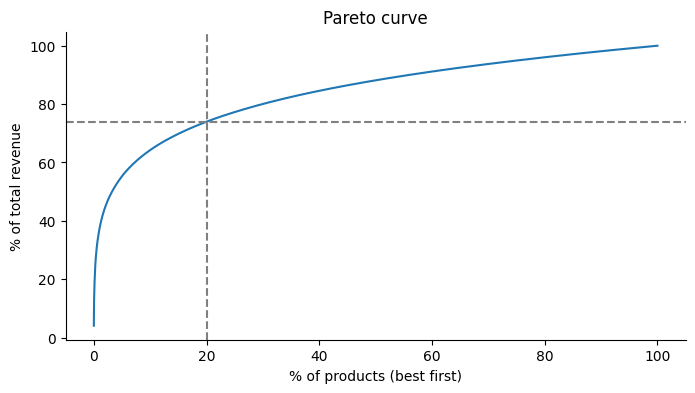

In [17]:
sorted_rev = np.sort(product_revenue)[::-1]
cum_share = np.cumsum(sorted_rev) / sorted_rev.sum()
top20 = int(0.2 * len(sorted_rev))
print(f"Top 20% of products generate {cum_share[top20 - 1]:.0%} of revenue")

plt.plot(np.linspace(0, 100, len(cum_share)), cum_share * 100)
plt.axvline(20, color="gray", ls="--"); plt.axhline(cum_share[top20 - 1] * 100, color="gray", ls="--")
plt.xlabel("% of products (best first)"); plt.ylabel("% of total revenue"); plt.title("Pareto curve")
plt.show()

## The Central Limit Theorem (why the normal is everywhere)
Even if individual customers are wildly skewed, the **average of a sample** of customers is approximately normal. This is what lets us build confidence intervals.

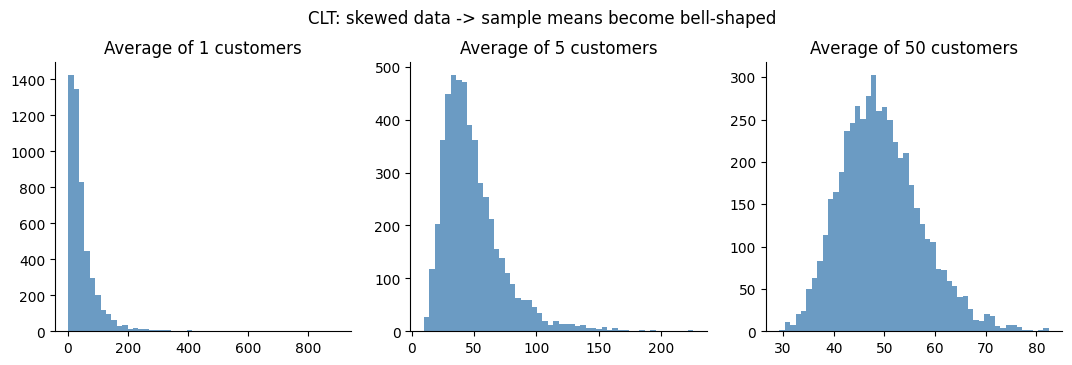

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(13, 3.5))
for ax, n in zip(axes, [1, 5, 50]):
    means = rng.choice(revenue_per_customer, size=(5_000, n)).mean(axis=1)
    ax.hist(means, bins=50, color="steelblue", alpha=0.8)
    ax.set_title(f"Average of {n} customers")
plt.suptitle("CLT: skewed data -> sample means become bell-shaped", y=1.03)
plt.show()

## The t-distribution and confidence intervals
We usually **don't know** the true population σ, and our samples are often small. The t-distribution is like the normal but with fatter tails to account for that extra uncertainty. With more data it becomes the normal.

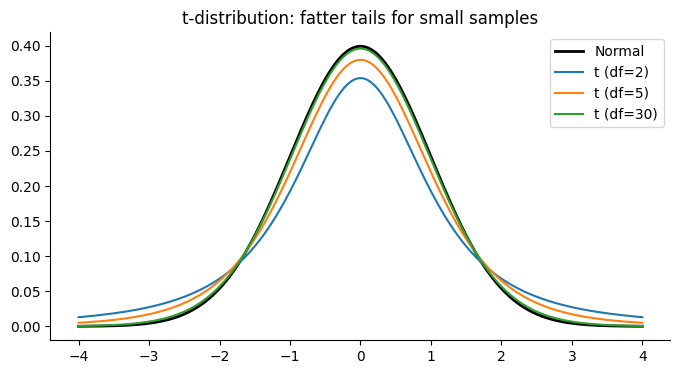

In [19]:
x = np.linspace(-4, 4, 400)
plt.plot(x, stats.norm.pdf(x), "k", lw=2, label="Normal")
for df_ in [2, 5, 30]:
    plt.plot(x, stats.t.pdf(x, df_), label=f"t (df={df_})")
plt.legend(); plt.title("t-distribution: fatter tails for small samples"); plt.show()

**Business question:** We surveyed 25 customers about monthly spend. What's a 95% confidence interval for the average spend of *all* customers?

In [20]:
survey = rng.choice(revenue_per_customer, size=25)
n, mean, se = len(survey), survey.mean(), stats.sem(survey)
lo, hi = stats.t.interval(0.95, df=n - 1, loc=mean, scale=se)
print(f"Sample mean: ${mean:.2f}")
print(f"95% CI for true mean: ${lo:.2f} to ${hi:.2f}")
print(f"(True population mean in our fake data: ${revenue_per_customer.mean():.2f})")

Sample mean: $57.47
95% CI for true mean: $34.55 to $80.39
(True population mean in our fake data: $49.19)


Interpretation: if we repeated this survey many times, ~95% of intervals built this way would contain the true average.
It is **not** "95% chance the true mean is in this particular interval".

## 🟡 Intermediate Exercises
1. A website averages 3 crashes per week (Poisson). What's the probability of a week with **zero** crashes? With **6 or more**?
2. Call center hold times are exponential with mean 4 minutes. What % of callers wait longer than 10 minutes? What's the 90th-percentile wait?
3. An email campaign goes to 2,000 people with a historical open rate of 22%. You got 400 opens. Compute P(400 or fewer). Would you be worried?
4. Repeat the confidence-interval example with a sample of 200 customers instead of 25. What happens to the width of the interval, and why?

In [21]:
# Your code here

---
# 🔴 Advanced: Working With Real (Messy) Data

## A1. Which distribution fits my data?
In real life nobody tells you the distribution. You get data and have to figure it out.
Below is a "mystery" dataset of session lengths (minutes). We'll fit several candidates and compare them.

In [22]:
mystery = rng.gamma(shape=2.2, scale=4.0, size=2_000)   # pretend we don't know this

candidates = {
    "norm": stats.norm,
    "expon": stats.expon,
    "lognorm": stats.lognorm,
    "gamma": stats.gamma,
}

rows = []
for name, dist in candidates.items():
    params = dist.fit(mystery, floc=0) if name != "norm" else dist.fit(mystery)
    loglik = np.sum(dist.logpdf(mystery, *params))
    k = len(params) - (0 if name == "norm" else 1)   # floc=0 isn't a free parameter
    aic = 2 * k - 2 * loglik
    ks = stats.kstest(mystery, name, args=params).statistic
    rows.append({"dist": name, "AIC": aic, "KS stat": ks, "params": np.round(params, 3)})

results = pd.DataFrame(rows).sort_values("AIC")
results

,dist,AIC,KS stat,params
3,gamma,12156.877044,0.013933,"[2.227, 0.0, 3.999]"
2,lognorm,12284.955453,0.052002,"[0.745, 0.0, 6.999]"
1,expon,12748.848329,0.161383,"[0.0, 8.906]"
0,norm,12913.590927,0.100020,"[8.906, 6.101]"


**Lower AIC = better fit** (it rewards fit and penalizes extra parameters). Let's check visually too:

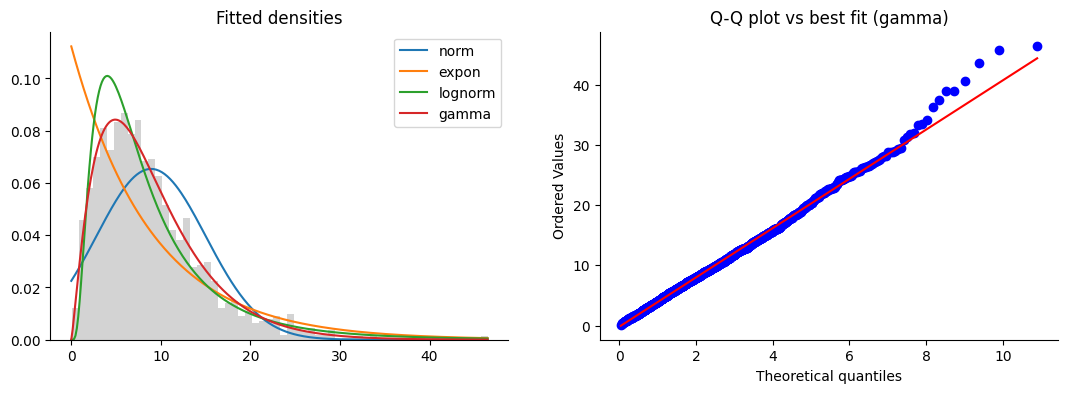

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
xs = np.linspace(0, mystery.max(), 300)
axes[0].hist(mystery, bins=60, density=True, color="lightgray")
for name, dist in candidates.items():
    params = dist.fit(mystery, floc=0) if name != "norm" else dist.fit(mystery)
    axes[0].plot(xs, dist.pdf(xs, *params), label=name)
axes[0].legend(); axes[0].set_title("Fitted densities")

best = results.iloc[0]["dist"]
stats.probplot(mystery, dist=candidates[best], sparams=candidates[best].fit(mystery, floc=0)[:-2], plot=axes[1])
axes[1].set_title(f"Q-Q plot vs best fit ({best})")
plt.show()

On a Q-Q plot, points on the diagonal line mean the fit is good; curving away at the ends means the tails are wrong.
⚠️ With big datasets, formal tests (KS p-values) will reject *every* distribution for tiny deviations. Use AIC + plots + business sense.

## A2. Is my count data really Poisson? (Overdispersion)
A Poisson has **variance = mean**. Real business counts (orders per day) are often *more* variable because of weekends, promos, weather. That's called **overdispersion**, and the **Negative Binomial** handles it.

mean = 40.3, variance = 341.0, ratio = 8.45


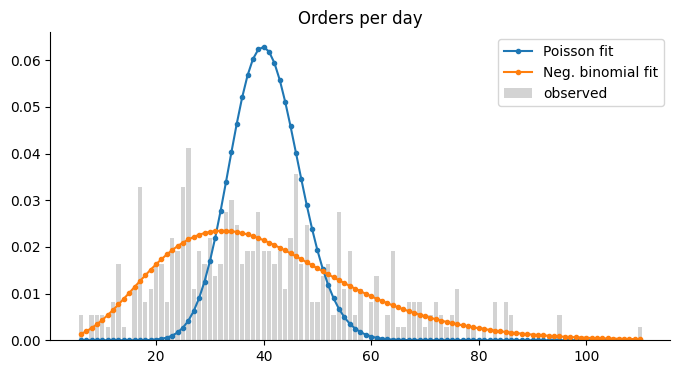

P(>70 orders)  Poisson says 0.0000,  NegBin says 0.0676


In [24]:
# Daily orders: rate itself varies day to day -> overdispersed
daily_rate = rng.gamma(shape=5, scale=40 / 5, size=365)
orders = rng.poisson(daily_rate)
print(f"mean = {orders.mean():.1f}, variance = {orders.var():.1f}, ratio = {orders.var() / orders.mean():.2f}")

# Method-of-moments fit for the negative binomial
m, v = orders.mean(), orders.var()
p_nb = m / v
r_nb = m * p_nb / (1 - p_nb)

ks = np.arange(orders.min(), orders.max() + 1)
vals, counts = np.unique(orders, return_counts=True)
plt.bar(vals, counts / len(orders), color="lightgray", label="observed")
plt.plot(ks, stats.poisson.pmf(ks, m), "o-", ms=3, label="Poisson fit")
plt.plot(ks, stats.nbinom.pmf(ks, r_nb, p_nb), "o-", ms=3, label="Neg. binomial fit")
plt.legend(); plt.title("Orders per day"); plt.show()

print(f"P(>70 orders)  Poisson says {stats.poisson.sf(70, m):.4f},  NegBin says {stats.nbinom.sf(70, r_nb, p_nb):.4f}")

A variance/mean ratio well above 1 is the red flag. Using Poisson here would badly **underestimate** the chance of a huge day, which is exactly the day you run out of inventory.

## A3. A/B test: frequentist vs. Bayesian
New checkout page (B) vs. old (A). Each visitor is a Bernoulli trial, so conversions are binomial.

In [25]:
n_A, n_B = 4_000, 4_000
conv_A = rng.binomial(n_A, 0.080)
conv_B = rng.binomial(n_B, 0.092)
pA, pB = conv_A / n_A, conv_B / n_B
print(f"A: {conv_A}/{n_A} = {pA:.3%}    B: {conv_B}/{n_B} = {pB:.3%}")

# --- Frequentist: two-proportion z-test ---
p_pool = (conv_A + conv_B) / (n_A + n_B)
se = np.sqrt(p_pool * (1 - p_pool) * (1 / n_A + 1 / n_B))
z = (pB - pA) / se
p_value = 2 * stats.norm.sf(abs(z))
print(f"\nz = {z:.2f}, two-sided p-value = {p_value:.4f}")

A: 338/4000 = 8.450%    B: 388/4000 = 9.700%

z = 1.95, two-sided p-value = 0.0516


P(B is better than A)      = 97.3%
Expected relative lift     = 15.0%
95% credible interval lift = -0.2% to 31.9%


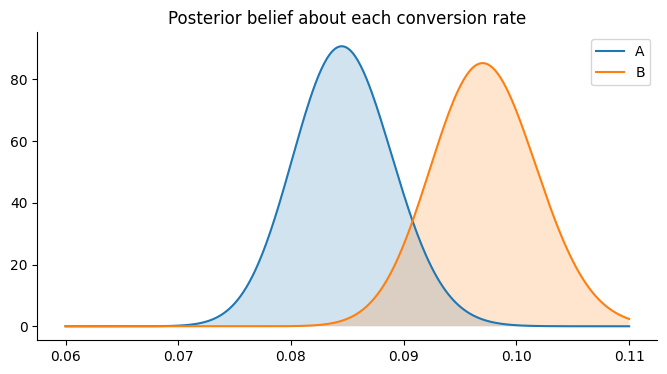

In [26]:
# --- Bayesian: Beta-Binomial ---
# Start with a flat Beta(1,1) prior, update with observed successes/failures
post_A = stats.beta(1 + conv_A, 1 + n_A - conv_A)
post_B = stats.beta(1 + conv_B, 1 + n_B - conv_B)

draws_A = post_A.rvs(100_000, random_state=1)
draws_B = post_B.rvs(100_000, random_state=2)
lift = (draws_B - draws_A) / draws_A

print(f"P(B is better than A)      = {(draws_B > draws_A).mean():.1%}")
print(f"Expected relative lift     = {lift.mean():.1%}")
print(f"95% credible interval lift = {np.percentile(lift, 2.5):.1%} to {np.percentile(lift, 97.5):.1%}")

xs = np.linspace(0.06, 0.11, 400)
plt.plot(xs, post_A.pdf(xs), label="A"); plt.plot(xs, post_B.pdf(xs), label="B")
plt.fill_between(xs, post_A.pdf(xs), alpha=0.2); plt.fill_between(xs, post_B.pdf(xs), alpha=0.2)
plt.title("Posterior belief about each conversion rate"); plt.legend(); plt.show()

Same data, two framings:
- **Frequentist:** "If A and B were truly equal, results this extreme would happen p% of the time."
- **Bayesian:** "Given the data, there's an X% chance B is better." Product managers usually find this one easier to act on.

💬 **Discussion:** With this seed the p-value lands just above 0.05 ("not significant") while the Bayesian view says B is ~97% likely to be better. Should we ship B? What does a hard 0.05 cutoff hide?

## A4. Bootstrapping: confidence intervals without assuming a distribution
The t-interval assumes the sample mean is roughly normal. For a **median** of skewed data there's no neat formula, so we resample our own data thousands of times.

Sample median: $35.20
95% bootstrap CI for median: $25.21 to $49.08
scipy.stats.bootstrap:       $25.21 to $48.29


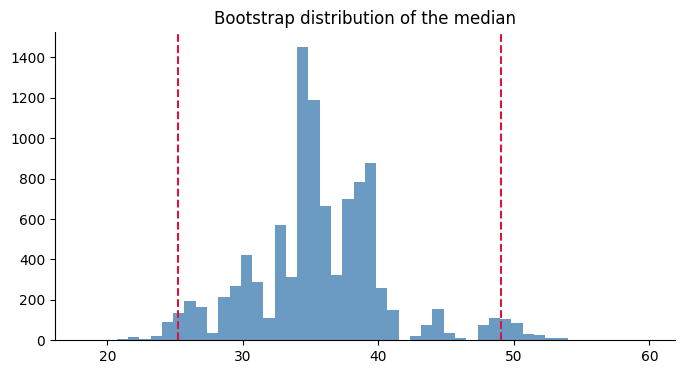

In [27]:
sample = rng.choice(revenue_per_customer, size=60)

boot_medians = np.array([
    np.median(rng.choice(sample, size=len(sample), replace=True))
    for _ in range(10_000)
])
lo, hi = np.percentile(boot_medians, [2.5, 97.5])
print(f"Sample median: ${np.median(sample):.2f}")
print(f"95% bootstrap CI for median: ${lo:.2f} to ${hi:.2f}")

# scipy has this built in too
res = stats.bootstrap((sample,), np.median, confidence_level=0.95, random_state=0)
print(f"scipy.stats.bootstrap:       ${res.confidence_interval.low:.2f} to ${res.confidence_interval.high:.2f}")

plt.hist(boot_medians, bins=50, color="steelblue", alpha=0.8)
plt.axvline(lo, color="crimson", ls="--"); plt.axvline(hi, color="crimson", ls="--")
plt.title("Bootstrap distribution of the median"); plt.show()

## A5. Monte Carlo: combining distributions to forecast revenue
Real questions combine several random pieces. **Will we hit $250k revenue next month?**
- Orders per day ~ Negative Binomial (from A2)
- Each order's value ~ Log-normal
- 30 days

P(hit $250,000) = 9.5%
Median forecast: $223,692   (90% range: $192,787 to $257,119)


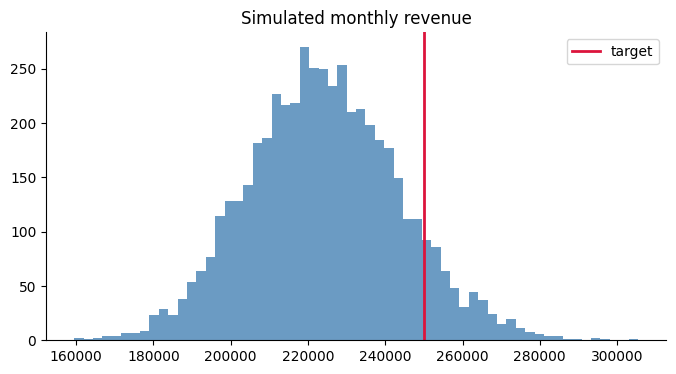

In [28]:
n_sims = 5_000
days = 30
target = 250_000

monthly_revenue = np.empty(n_sims)
for i in range(n_sims):
    daily_orders = stats.nbinom.rvs(r_nb, p_nb, size=days, random_state=rng)
    total_orders = daily_orders.sum()
    order_values = rng.lognormal(mean=4.9, sigma=0.8, size=total_orders)
    monthly_revenue[i] = order_values.sum()

p_hit = (monthly_revenue >= target).mean()
p5, p50, p95 = np.percentile(monthly_revenue, [5, 50, 95])
print(f"P(hit ${target:,}) = {p_hit:.1%}")
print(f"Median forecast: ${p50:,.0f}   (90% range: ${p5:,.0f} to ${p95:,.0f})")

plt.hist(monthly_revenue, bins=60, color="steelblue", alpha=0.8)
plt.axvline(target, color="crimson", lw=2, label="target")
plt.legend(); plt.title("Simulated monthly revenue"); plt.show()

Instead of a single-number forecast ("we'll make $X"), you give leadership a **range and a probability**, which is far more honest and useful.

## 🔴 Advanced Exercises
1. Generate `rng.weibull(1.5, 3000) * 10` as "equipment lifetimes (months)". Add `stats.weibull_min` to the candidates in A1. Does it win on AIC?
2. In A3, how many visitors per group would you need for the Bayesian P(B better) to exceed 99% on average? Write a loop that simulates it.
3. In A5, marketing says a promo will raise the average order *count* by 10% but lower order *value* by 8%. Simulate both scenarios. Should we run the promo?
4. Bootstrap a 95% CI for the **90th percentile** of `sample` in A4. Why is it so much wider than the CI for the median?

In [29]:
# Your code here

---
### Key takeaways
- Match the distribution to the **story**: counts → binomial/Poisson, waits → exponential, money → log-normal/Pareto, averages → normal/t.
- Plan for the **tails**, not the average (staffing, SLAs, inventory).
- For skewed data, the **median** is "typical"; the mean is for totals.
- When formulas get hard, **simulate** (bootstrap, Monte Carlo).